# Simply visualize simulation results to see if spectra look reasonable

In [1]:
#pip install h5py nibabel pandas glob2 regex
import numpy as np
import matplotlib.pyplot as plt
import h5py
import nibabel as nib
import scipy.io

In [2]:
# Load data

path = '../data/3T/'
version = 'v_1.0'

#! pip install h5py nibabel pandas glob2 regex
p = '/workspace/walinet/data/3T/Vol01_WB/Res64x64_Thick/TrainData/'+'TrainData_'+version+'.h5'

fh = h5py.File(p, 'r')
print(fh.keys())

print(fh['spectra'].shape)
spectra = np.array(fh['spectra'][:1000,:])
lipid_proj = np.array(fh['lipid_proj'][:1000,:])
lipid = np.array(fh['lipid'][:1000,:])
water = np.array(fh['water'][:1000,:])
metab = np.array(fh['metab'][:1000,:])

<KeysViewHDF5 ['lipid', 'lipid_proj', 'lipid_projOP', 'metab', 'spectra', 'water']>
(99828, 288)


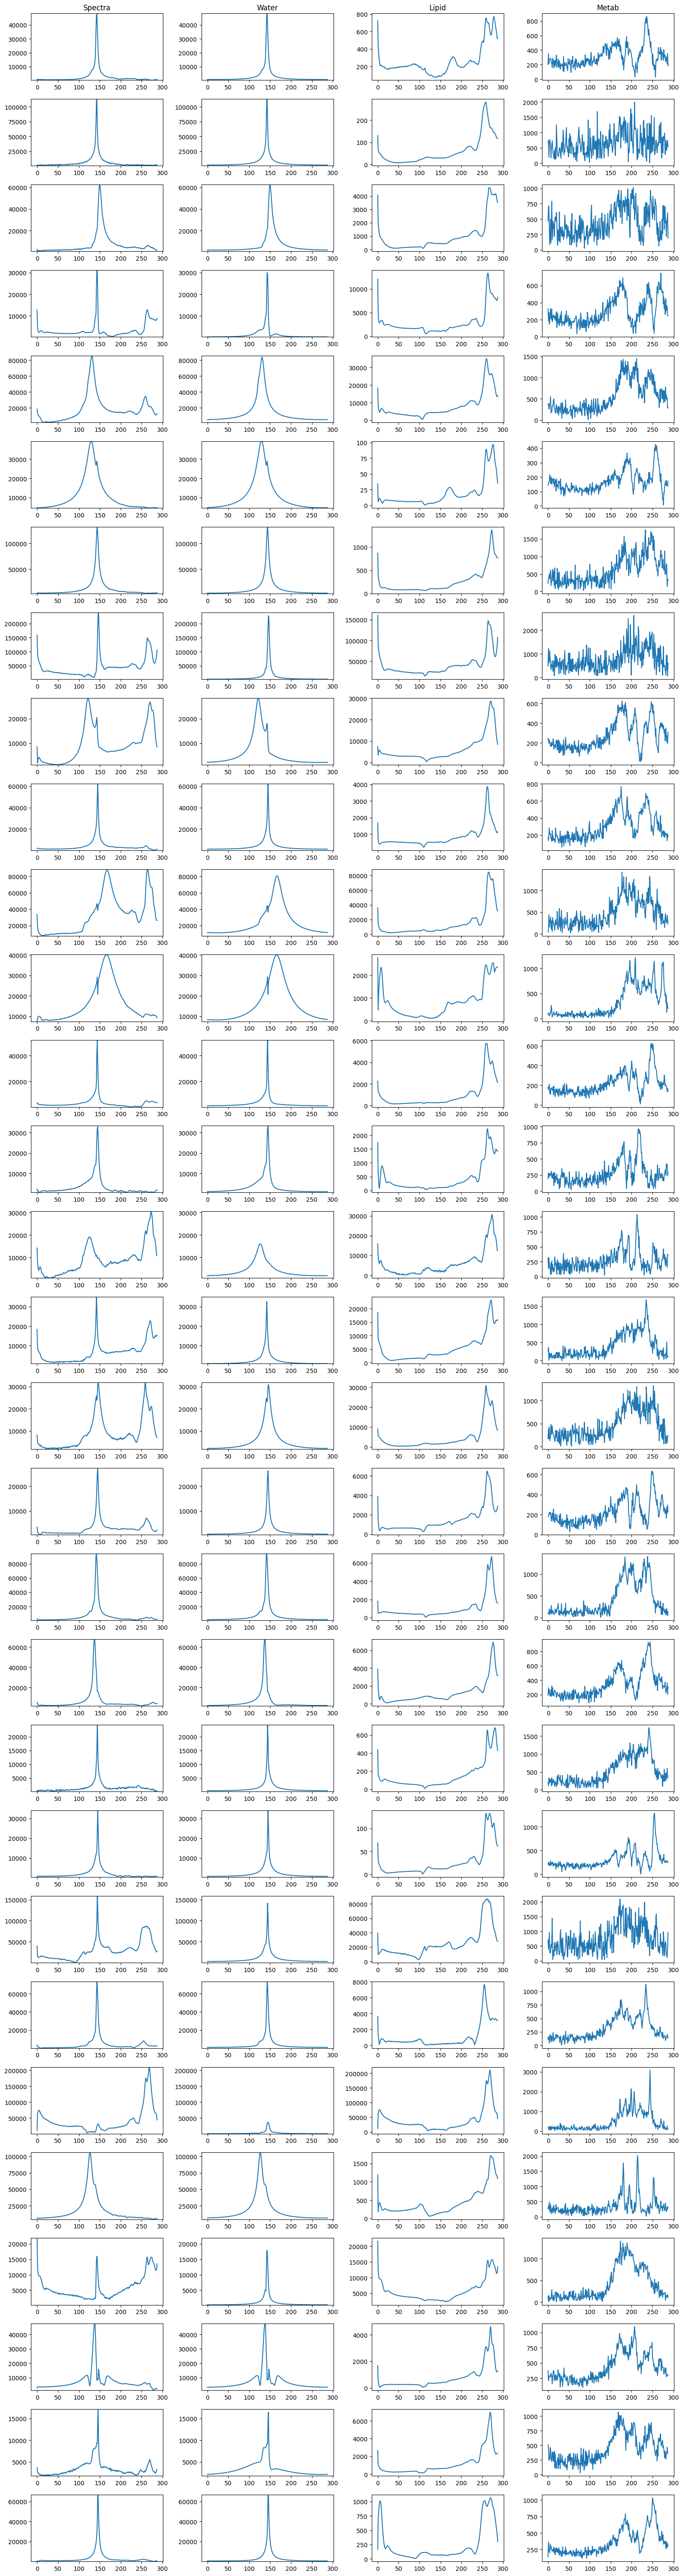

In [9]:
import matplotlib.pyplot as plt
import numpy as np

n_plot = 30

fig, axes = plt.subplots(n_plot, 4, figsize=(16, 2*n_plot))

for i in range(n_plot):
    spec = np.abs(spectra[i])
    wat  = np.abs(water[i])
    lip  = np.abs(lipid[i])
    met  = np.abs(metab[i])

    # gemeinsame Skala für Spectra + Water
    ymin = min(spec.min(), wat.min())
    ymax = max(spec.max(), wat.max())

    # Spectra
    axes[i,0].plot(spec)
    axes[i,0].set_ylim(ymin, ymax)
    if i == 0:
        axes[i,0].set_title("Spectra")

    # Water
    axes[i,1].plot(wat)
    axes[i,1].set_ylim(ymin, ymax)
    if i == 0:
        axes[i,1].set_title("Water")

    # Lipid → eigene Skala
    axes[i,2].plot(lip)
    if i == 0:
        axes[i,2].set_title("Lipid")

    # Metabolite → eigene Skala
    axes[i,3].plot(met)
    if i == 0:
        axes[i,3].set_title("Metab")

plt.tight_layout()
plt.show()